In [1]:
import pandas as pd
import numpy as np
import sys
from numba import njit, prange
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.metrics.fidelity.utils import extract_metadata
metadata_path = "../../Data/data_processed/Original_data/feature_metadata.json"
data_path = "../../Data/data_processed/Original_data/integrated_data_jobim.csv"

or_df = pd.read_csv("../../Data/data_processed/Original_data/integrated_data_jobim.csv", index_col = 0)
metadata = extract_metadata(or_df, metadata_path)
categorical_features = metadata.get("ordinal_categorical") + metadata.get("dummy_categorical") + metadata.get("missing_categorical")
numerical_features = metadata.get("numerical")

In [2]:
print(f"Number of dummy cols {len(metadata.get('dummy_categorical'))}")
print(f"Number of ordinal cols {len(metadata.get('ordinal_categorical'))}")
print(f"Number of numerical cols {len(metadata.get('numerical'))}")
print(f"Number of missing indicators {len(metadata.get('missing_categorical'))}")
print(f"Number of columns {len(categorical_features)+len(numerical_features)}")

Number of dummy cols 10
Number of ordinal cols 3
Number of numerical cols 40937
Number of missing indicators 6
Number of columns 40956


# **1. Data Processing**

## **1.1. Remove identical features**

In [3]:
from utils import check_duplicates

num_df = or_df[numerical_features]
duplicated_dict = check_duplicates(num_df)

subset = or_df[numerical_features]
dup_mask_numeric = subset.T.duplicated(keep='first')
keep_mask_all = pd.Series(True, index=or_df.columns)
keep_mask_all.loc[dup_mask_numeric[dup_mask_numeric].index] = False
# DataFrame sau khi loại duplicate chỉ trong num_cols
df_cleaned_identical = or_df.loc[:, keep_mask_all]

print(df_cleaned_identical.shape)

# Get removed features (all columns)
removed_features = keep_mask_all[~keep_mask_all].index.tolist()
identical_df = or_df[removed_features]
identical_df.to_csv("Identical_features.csv", index = True)

Grouping genes with identical expression values...


Processing duplicates: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2085/2085 [00:00<00:00, 20313.69it/s]


(310, 39294)


In [4]:
clean_metadata = extract_metadata(df_cleaned_identical, metadata_path)
clean_categorical_features = clean_metadata.get("ordinal_categorical") + clean_metadata.get("dummy_categorical") + clean_metadata.get("missing_categorical")
clean_numerical_features = clean_metadata.get("numerical")

### **1.2. Data Encoding**

In [5]:
from sklearn.preprocessing import LabelEncoder
def encode_categorical_columns(data: pd.DataFrame, categorical_columns: list):
    """
    Encode multiple categorical columns in a DataFrame using LabelEncoder.

    Args:
        data (pd.DataFrame): The DataFrame containing the data to be encoded.
        categorical_columns (list): List of column names to encode.

    Returns:
        pd.DataFrame: DataFrame with categorical columns encoded as integers.
        dict: A dictionary mapping column names to their LabelEncoders.

    Raises:
        ValueError: If a specified column does not exist in the DataFrame.
    """
    encoders = {}
    encoded_data = data.copy()

    for col in categorical_columns:
        if col not in encoded_data.columns:
            raise ValueError(f"Column '{col}' not found in the DataFrame.")
        
        encoder = LabelEncoder()
        encoded_data[col] = encoder.fit_transform(encoded_data[col].astype(str))
        encoders[col] = encoder

    return encoded_data, encoders

encoded_cat_df, encoders = encode_categorical_columns(df_cleaned_identical[clean_categorical_features], clean_categorical_features)

### **1.3. Data Normalization**

In [6]:
from sklearn.preprocessing import StandardScaler
import pickle
def normalization(data: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(data, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")
    try:  
        scaler = StandardScaler()
        scaled_num_df = scaler.fit_transform(data)
        with open("avatar_normalizationer.pkl", "wb") as f:
            pickle.dump(scaler, f)
        scaled_num_df = pd.DataFrame(scaled_num_df, columns = data.columns, index = data.index)
        return scaled_num_df
    except Exception as e: 
        raise ValueError(f"Error in normalizing numerical features: {e}")


num_df_cleaned_identical = df_cleaned_identical[clean_numerical_features]
scaled_num_df = normalization(num_df_cleaned_identical)
scaled_num_df.head()

,PFS,OS,Age,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
Patient_ID,,,,,,,,,,,,,,,,,,,,,
G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.442346,-0.057158,0.015438,-0.830622,0.369811,-0.241128,-0.12091,0.018994,0.02812,-0.487158,...,-0.456877,-0.073693,-1.660184,-1.010088,0.406583,0.016714,-0.451830,-0.314134,0.014564,-1.892162
G138701_RCCBMS-00097-T_v1_RNA_OnPrem,-0.190070,0.491514,0.497567,0.661023,0.307975,-0.241128,-0.12091,0.018994,0.02812,-0.487158,...,0.976433,0.975964,0.625872,1.262803,0.869441,0.016714,0.812325,0.648156,0.014564,1.110525
G138701_RCCBMS-00141-T_v1_RNA_OnPrem,5.155865,2.063295,0.015438,0.161379,-0.989567,-0.241128,-0.12091,0.018994,0.02812,-0.487158,...,0.570333,0.328262,0.377905,0.661102,0.633969,0.016714,0.653854,0.314914,0.014564,0.732038
G138701_RCCBMS-00099-T_v1_RNA_OnPrem,-0.591950,-1.228732,-0.177414,-0.830622,-1.100268,-0.241128,-0.12091,0.018994,0.02812,1.423996,...,0.207209,0.167725,0.566153,1.241272,0.460550,0.016714,0.690214,0.367474,0.014564,0.511579
G138701_RCCBMS-00163-T_v1_RNA_OnPrem,-0.174493,1.838986,1.365399,-0.830622,-0.469457,-0.241128,-0.12091,0.018994,0.02812,-0.487158,...,-2.665545,-1.862492,-1.660184,-1.010088,-0.367736,0.016714,-1.342956,-2.266501,0.014564,-1.892162


In [7]:
processed_df = pd.concat([encoded_cat_df, scaled_num_df], axis = 1)

# **2. Correlation Calculation**

### **2.1. Column indices**

In [8]:
from SynOmics.utils import get_column_indices

categorical_indices = get_column_indices(processed_df, clean_categorical_features)
numerical_indices = get_column_indices(processed_df, clean_numerical_features)

In [9]:
from SynOmics.Preprocess.Correlations import MixedCorrelation
from utils import split_clusters_by_size
from scipy.cluster.hierarchy import ward, fcluster, average

compute_correlations = MixedCorrelation(categorical_indices, numerical_indices, method = "spearman", n_bins = 10)
corr_matrix = compute_correlations.compute(processed_df)
distance_matrix = 1 - np.abs(corr_matrix)
sqr_corr_mat = MixedCorrelation.get_squareform(distance_matrix)
Z = average(sqr_corr_mat.astype(np.float64))
#Save Z
np.save("Z.npy", Z)

# **3. Feature Clustering**

In [114]:
threshold = 3700
clusters = split_clusters_by_size(Z, threshold)

cluster_counts = []
for cluster in clusters:
    cluster_counts.append(len(cluster))

print(f"Number of clusters {len(cluster_counts)}")
print(f"The largest cluster has {max(cluster_counts)}")
print(f"The smallest cluster has {min(cluster_counts)}")

def create_labels_as_clusters(clusters, n_samples):
    labels = np.zeros(n_samples)
    for cluster_id, members in enumerate(clusters):
        for member in members:
            labels[member]=cluster_id 
    return labels

labels = create_labels_as_clusters(clusters, n_samples = processed_df.shape[1])

Number of clusters 3310
The largest cluster has 3698
The smallest cluster has 1


In [117]:
invalid_clusters = []
for invalid_member in range(1,5):
    invalid_cluster_as_i = [cluster for cluster in clusters if len(cluster)==invalid_member][::-1]
    invalid_clusters += invalid_cluster_as_i
# invalid_clusters = [cluster for cluster in clusters if len(cluster)<5]
valid_clusters = [cluster for cluster in clusters if len(cluster)>=5]    

In [116]:
from itertools import product
import copy
from tqdm import tqdm
import numpy as np

# Deep copy to avoid modifying the original valid_clusters
new_valid_clusters = copy.deepcopy(valid_clusters)
indices = []

# Maximum size constraint
MAX_SIZE = 3700

for invalid_cluster in tqdm(invalid_clusters):
    distances = []

    # Calculate distances from the invalid cluster to all valid clusters
    for new_valid_cluster in new_valid_clusters:
        # Generate pairs of elements between clusters
        pairs = list(product(invalid_cluster, new_valid_cluster))
        rows, cols = np.array(pairs, dtype=int).T
        score = np.mean(distance_matrix[rows, cols].tolist())
        distances.append(score)
    
    # Sort clusters by distance (ascending) to try closest clusters first
    ranked_indices = np.argsort(distances)

    # Find the closest valid cluster that can accommodate the invalid cluster
    for idx_closest_cluster in ranked_indices:
        # Check if adding the invalid cluster exceeds the size constraint
        if len(new_valid_clusters[idx_closest_cluster]) + len(invalid_cluster) <= MAX_SIZE:
            # Merge the invalid cluster into the valid cluster
            new_valid_clusters[idx_closest_cluster].extend(invalid_cluster)
            indices.append(idx_closest_cluster)
            break
    else:
        # If no valid cluster can accommodate the invalid cluster, log or handle it
        print(f"Invalid cluster {invalid_cluster} could not be merged.")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2915/2915 [01:28<00:00, 32.97it/s]


In [119]:
new_cluster_counts = []
for cluster in new_valid_clusters:
    new_cluster_counts.append(len(cluster))

print(f"Number of clusters {len(new_cluster_counts)}")
print(f"The largest cluster has {max(new_cluster_counts)}")
print(f"The smallest cluster has {min(new_cluster_counts)}")

Number of clusters 395
The largest cluster has 3700
The smallest cluster has 5


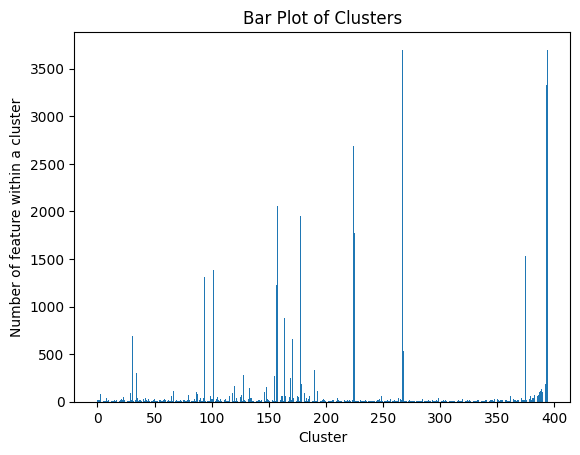

In [120]:
import matplotlib.pyplot as plt

x = range(len(new_cluster_counts))

plt.bar(x, new_cluster_counts)
plt.xlabel('Cluster')
plt.ylabel('Number of feature within a cluster')
plt.title('Bar Plot of Clusters')
plt.show()

In [121]:
labels = create_labels_as_clusters(new_valid_clusters, n_samples = processed_df.shape[1])
df_cluster = pd.DataFrame(list(zip(processed_df.columns, labels)),
                                  columns=['feature', 'cluster'])
df_cluster.to_csv("df_cluster_avatar.csv", index = False)

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def heatmap_visualization(matrix, title, title_fontsize, label_fontsize, heatmap_name, cluster_sizes = None, save=True):
    """
    Visualize a heatmap of the input matrix and bold the borders between clusters.

    Args:
        matrix (np.ndarray or pd.DataFrame): Data matrix to visualize.
        title (str): Title of the heatmap.
        title_fontsize (int): Font size for the title.
        label_fontsize (int): Font size for the axis labels.
        heatmap_name (str): Name to use for saving the figure.
        cluster_sizes (list or np.ndarray): List of number of members in each cluster (in order).
        save (bool, optional): Whether to save the figure. Defaults to True.

    Returns:
        None

    Raises:
        ValueError: If matrix is not 2D or cluster_sizes do not sum to matrix dimension.
    """
    print(f"Matrix Shape {matrix.shape}")
    fig, ax = plt.subplots(figsize=(30, 20))
    sns.heatmap(matrix,
                annot=False, 
                cmap='coolwarm',
                linewidths=0.5, 
                fmt=".1f",
                annot_kws={"size": 2}, 
                vmin=-1, vmax=1,
                ax=ax)
    
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel("Cluster", fontsize=label_fontsize)
    ax.set_ylabel("Cluster", fontsize=label_fontsize)
    ax.grid(alpha=0.3)
    
    # Draw bold lines between clusters
    if cluster_sizes != []:
        boundaries = np.cumsum(cluster_sizes)[:-1]
        for b in boundaries:
            # horizontal boundary
            ax.axhline(b, color='black', linewidth=5)
            # vertical boundary
            ax.axvline(b, color='black', linewidth=5)

    plt.tight_layout()
    if save:
        plt.savefig(f"{heatmap_name}.png", dpi=300, bbox_inches='tight')
    plt.show() 

In [122]:
clusters_id, members = np.unique(labels, return_counts = True)  

In [142]:
# Get all features in cluster order
features_in_cluster = []
cluster_assignments = df_cluster['cluster'].values.copy()

# Create mapping from feature name to index
feature_to_idx = {feat: idx for idx, feat in enumerate(processed_df.columns)}

clusters_inspect = clusters_id[0:200]
for cluster_i in clusters_inspect:
    cluster_features = df_cluster[df_cluster['cluster'] == cluster_i]["feature"].tolist()
    features_in_cluster.extend(cluster_features)

        # Set cluster assignments
    for feat in cluster_features:
        if feat in feature_to_idx:
            cluster_assignments[feature_to_idx[feat]] = cluster_i

df_as_clusters = processed_df[features_in_cluster]

In [143]:
metadata_19_24 = extract_metadata(df_as_clusters, metadata_path)
categorical_features_19_24 = metadata_19_24.get("ordinal_categorical") + metadata_19_24.get("dummy_categorical") + metadata_19_24.get("missing_categorical")
numerical_features_19_24 = metadata_19_24.get("numerical")

categorical_indices_19_24 = get_column_indices(df_as_clusters, categorical_features_19_24)
numerical_indices_19_24 = get_column_indices(df_as_clusters, numerical_features_19_24)

compute_correlations_19_24 = MixedCorrelation(categorical_indices_19_24, numerical_indices_19_24, method = "spearman", n_bins = 10)
corr_matrix_19_24 = compute_correlations_19_24.compute(df_as_clusters)
relation_matrix_19_24 = np.abs(corr_matrix_19_24)
relation_matrix_19_24_spearman = pd.DataFrame(relation_matrix_19_24,
                             columns=features_in_cluster,
                             index=features_in_cluster)

Matrix Shape (133, 133)


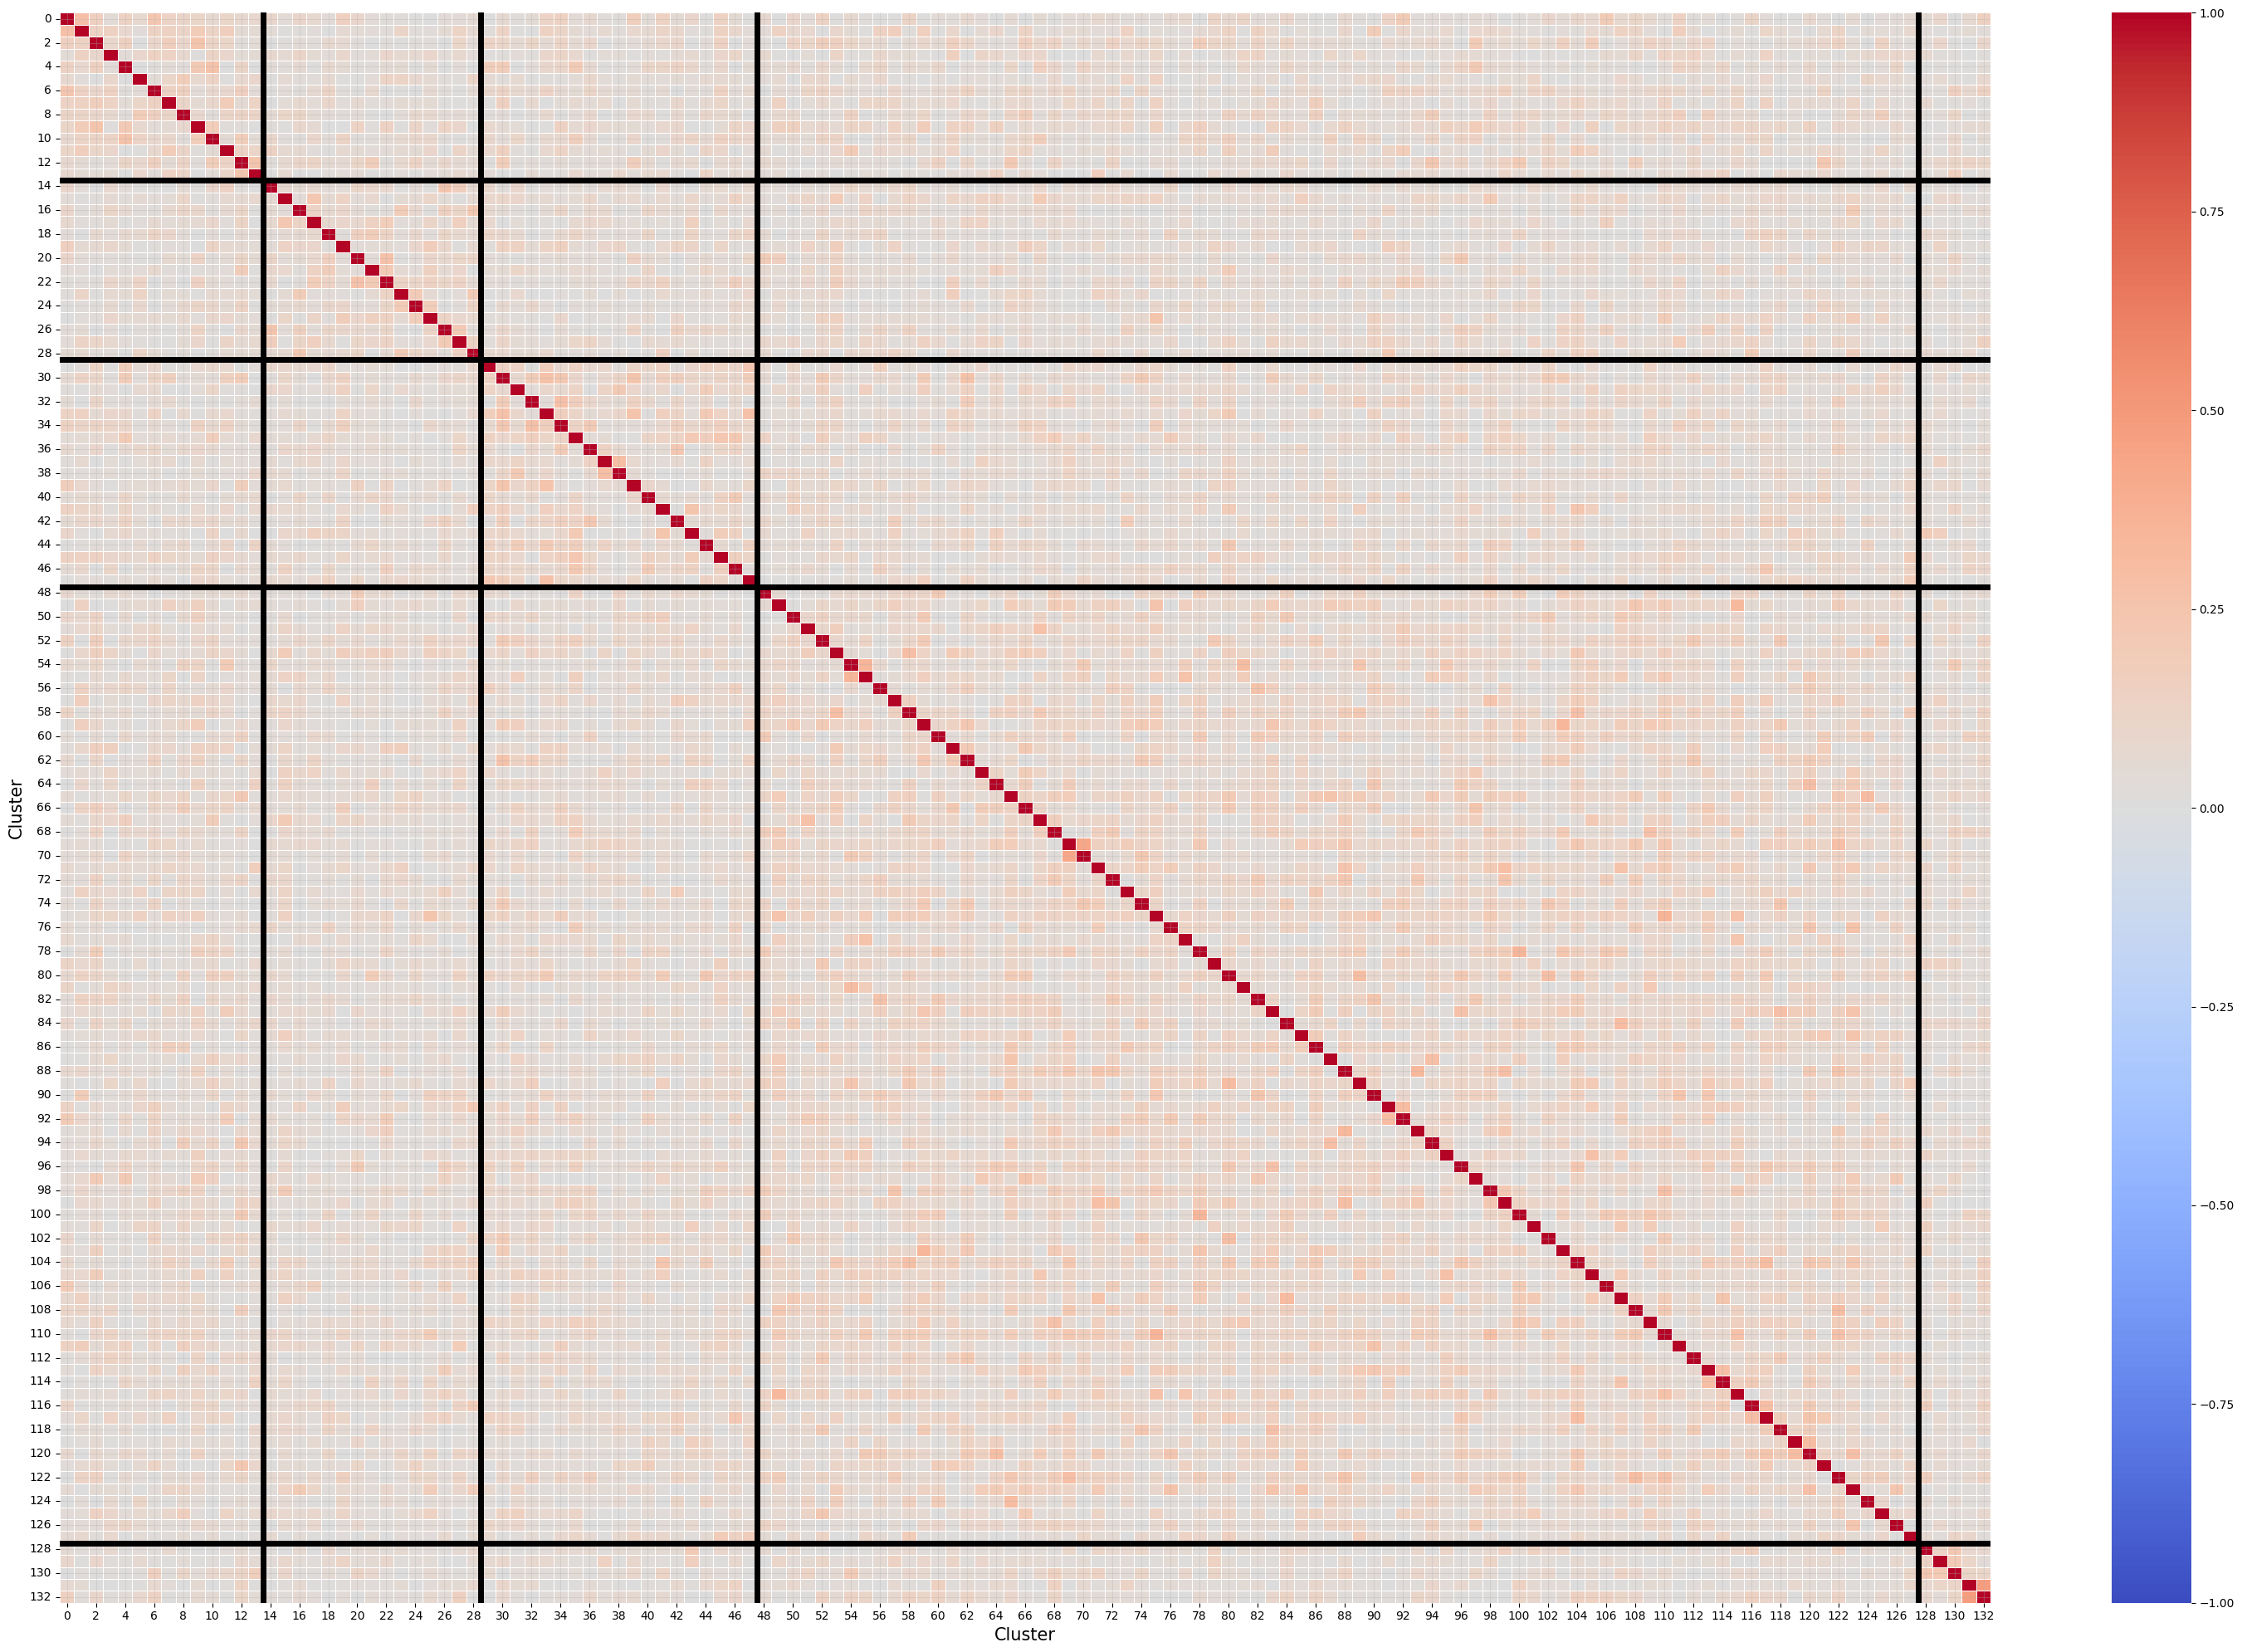

In [133]:
#Visualization
title = ""
title_fontsize = 20
label_fontsize = 15
heatmap_name = ""
heatmap_visualization(relation_matrix_19_24, title, title_fontsize, label_fontsize, heatmap_name,cluster_sizes = members[0:5], save = False)

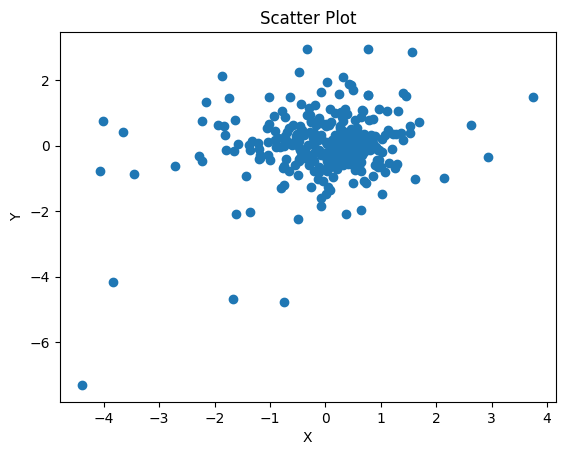

Spearman correlation: 0.0462, p-value: 0.4179
Pearson correlation: 0.2287, p-value: 0.0000


In [134]:
from scipy.stats import spearmanr, pearsonr
x = processed_df["ENSG00000198346.11"].values
y = processed_df["ENSG00000146426.19"].values
# Scatter plot
plt.scatter(x, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot')
plt.show()

# Calculate Spearman correlation
spearman_corr, spearman_p = spearmanr(x, y)
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4f}")

# Calculate Pearson correlation
pearson_corr, pearson_p = pearsonr(x, y)
print(f"Pearson correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4f}")

In [135]:
def vectorized_inter_relations_matrix(correlation_matrix, cluster_assignments, k, aggregation="mean"):
    """
    aggregation chỉ áp dụng cho inter-cluster; intra-cluster luôn dùng mean.
    """
    inter_relation_matrix = np.zeros((k, k), dtype=np.float64)

    for i in range(k):
        cluster_i_indices = np.where(cluster_assignments == i)[0]

        for j in range(i, k):
            cluster_j_indices = np.where(cluster_assignments == j)[0]

            if len(cluster_i_indices) > 0 and len(cluster_j_indices) > 0:
                correlations = correlation_matrix[np.ix_(cluster_i_indices, cluster_j_indices)]

                if i == j:
                    # Intra-cluster: Exclude diagonal, always use mean
                    mask = ~np.eye(len(cluster_i_indices), dtype=bool)
                    correlations_no_diag = correlations[mask]
                    if correlations_no_diag.size == 0:
                        value = 0.0
                    else:
                        value = np.mean(correlations_no_diag)
                    inter_relation_matrix[i, j] = value
                    inter_relation_matrix[j, i] = value
                else:
                    # Inter-cluster: use aggregation
                    if aggregation == "mean":
                        value = np.mean(correlations)
                    elif aggregation == "max":
                        value = np.max(correlations)
                    else:
                        raise ValueError("Unknown aggregation: %s" % aggregation)
                    inter_relation_matrix[i, j] = value
                    inter_relation_matrix[j, i] = value

    return inter_relation_matrix

def inter_relations_matrix_vectorized(relation_matrix, k, df_cluster, aggregation="mean"):
    """
    Drop-in replacement for your original inter_relations_matrix function.
    """
    # Convert to numpy and take absolute values
    correlation_matrix = np.abs(relation_matrix.values).astype(np.float64)

    # Create cluster assignments array
    feature_to_idx = {feat: idx for idx, feat in enumerate(relation_matrix.columns)}
    cluster_assignments = np.zeros(len(relation_matrix.columns), dtype=np.int64)

    for _, row in df_cluster.iterrows():
        feature = row['feature']
        cluster_id = row['cluster']
        if feature in feature_to_idx:
            cluster_assignments[feature_to_idx[feature]] = cluster_id

    # Call vectorized function
    return vectorized_inter_relations_matrix(correlation_matrix, cluster_assignments, k, aggregation=aggregation)

In [136]:
# Get all features in cluster order
features_in_cluster = []
cluster_assignments = df_cluster['cluster'].values.copy()

# Create mapping from feature name to index
feature_to_idx = {feat: idx for idx, feat in enumerate(processed_df.columns)}

clusters_inspect = clusters_id
for cluster_i in clusters_inspect:
    cluster_features = df_cluster[df_cluster['cluster'] == cluster_i]["feature"].tolist()
    features_in_cluster.extend(cluster_features)

        # Set cluster assignments
    for feat in cluster_features:
        if feat in feature_to_idx:
            cluster_assignments[feature_to_idx[feat]] = cluster_i

df_as_clusters = processed_df[features_in_cluster]

metadata_19_24 = extract_metadata(df_as_clusters, metadata_path)
categorical_features_19_24 = metadata_19_24.get("ordinal_categorical") + metadata_19_24.get("dummy_categorical") + metadata_19_24.get("missing_categorical")
numerical_features_19_24 = metadata_19_24.get("numerical")

categorical_indices_19_24 = get_column_indices(df_as_clusters, categorical_features_19_24)
numerical_indices_19_24 = get_column_indices(df_as_clusters, numerical_features_19_24)

compute_correlations_19_24 = MixedCorrelation(categorical_indices_19_24, numerical_indices_19_24, method = "spearman", n_bins = 10)
corr_matrix_19_24 = compute_correlations_19_24.compute(df_as_clusters)
relation_matrix_19_24 = np.abs(corr_matrix_19_24)
relation_matrix_full = pd.DataFrame(relation_matrix_19_24,
                             columns=features_in_cluster,
                             index=features_in_cluster)

inter_relation_matrix_vect = inter_relations_matrix_vectorized(np.abs(relation_matrix_full), k = len(clusters_id), df_cluster=df_cluster, aggregation="mean")

Matrix Shape (395, 395)


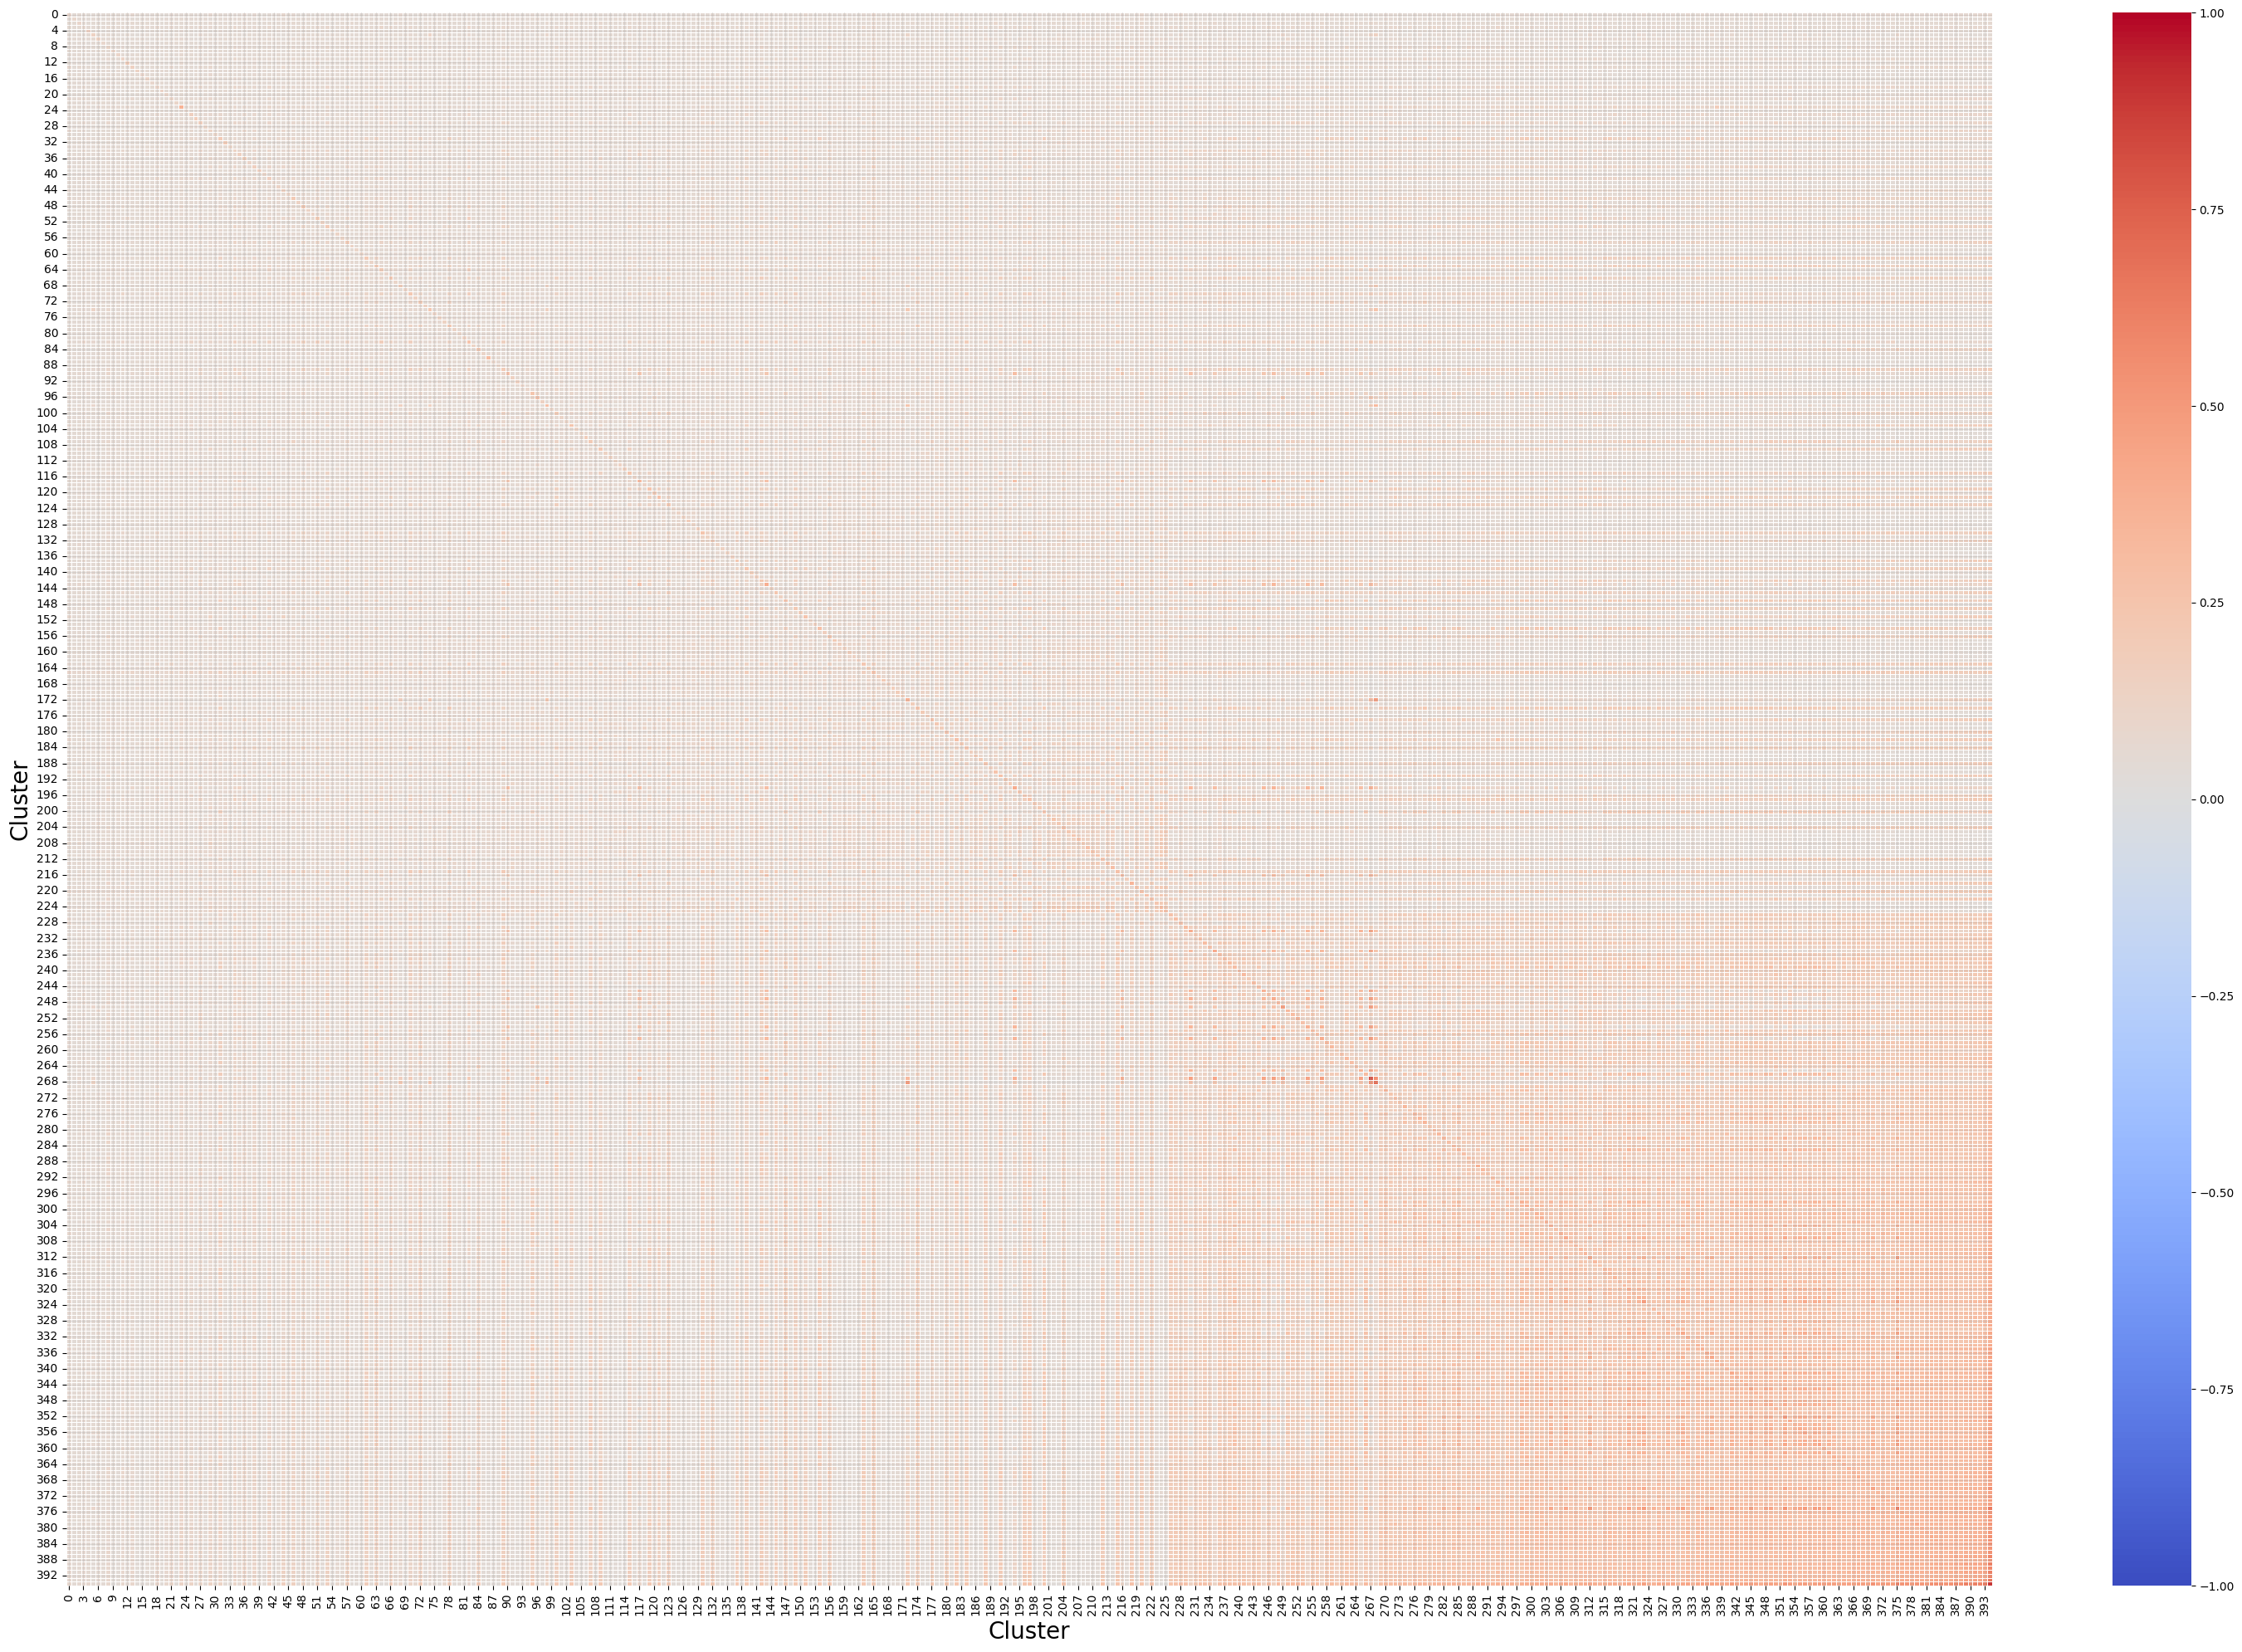

In [137]:
#Visualization
title = ""
title_fontsize = 30
label_fontsize = 20
heatmap_name = ""
heatmap_visualization(inter_relation_matrix_vect, title, title_fontsize, label_fontsize, heatmap_name,cluster_sizes = None, save = False)

In [138]:
def numba_validate_clusters(inter_relation_matrix, k):
    """Validate clusters using Numba"""
    validated_clusters = []
    unvalidated_clusters = []
    
    for i in k:
        intra_relation = inter_relation_matrix[i, i]
        max_inter_relation = 0.0
        
        # Find max inter-cluster relation
        for j in k:
            if i != j and inter_relation_matrix[i, j] > max_inter_relation:
                max_inter_relation = inter_relation_matrix[i, j]
        
        if intra_relation >= max_inter_relation:
            validated_clusters.append(i)
        else:
            unvalidated_clusters.append(i)
    
    return validated_clusters, unvalidated_clusters

def inter_intra_diff(validated_clusters, unvalidated_clusters):
    total_clusters = len(validated_clusters) + len(unvalidated_clusters)
    inter_intra_metric_value = len(validated_clusters) / total_clusters if total_clusters > 0 else 0.0
    return inter_intra_metric_value

validated_clusters, unvalidated_clusters = numba_validate_clusters(inter_relation_matrix_vect, k=clusters_id.astype(int))
print(f"Un validated cluster {unvalidated_clusters}")
print(inter_intra_diff(validated_clusters, unvalidated_clusters))

Un validated cluster [3, 5, 8, 15, 18, 29, 31, 34, 38, 68, 74, 89, 90, 94, 98, 100, 102, 105, 107, 124, 133, 152, 161, 166, 172, 185, 196, 216, 230, 231, 235, 242, 244, 245, 246, 247, 253, 254, 256, 257, 260, 261, 262, 263, 264, 265, 266, 269, 271, 272, 273, 275, 276, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393]
0.5822784810126582


In [123]:
import json
with open("duplicated_genes_dict.json", "r") as f:
    duplicated_genes_dict = json.load(f) 

In [124]:
features_as_cluster = []
for cluster_i in clusters_id:
    df_cluster_i = df_cluster[df_cluster["cluster"]==cluster_i]
    features_cluster_i = df_cluster_i["feature"].values.tolist()
    features_as_cluster.append(features_cluster_i)

In [125]:
#Assign duplicated values
seen_values = []
for k, v in duplicated_genes_dict.items():
    first_values = v[0]
    corr_cluster = df_cluster[df_cluster["feature"]==first_values]["cluster"].values.tolist()
    if corr_cluster != []:
        if k not in features_as_cluster[int(corr_cluster[0])]:
            features_as_cluster[int(corr_cluster[0])].append(k)
    else:
        print(f"Cannot find this feature {first_values}")

In [126]:
max_cluster = 100
min_cluster = 55
for cluster in features_as_cluster:
    value_count = len(cluster)
    if value_count <= min_cluster: 
        min_cluster = value_count
    if value_count >= max_cluster:
        max_cluster = value_count

print(f"Max cluster after appending identical features {max_cluster}")
print(f"Min cluster after appending identical features {min_cluster}")

Max cluster after appending identical features 4016
Min cluster after appending identical features 5


In [130]:
import json
with open("List_clusters_as_features_3700_spearman.json", "w", encoding="utf-8") as f:
    json.dump(features_as_cluster, f, ensure_ascii=False, indent=2)

In [139]:
counts = []
for cluster in  features_as_cluster:
    counts.append(len(cluster))

In [1]:
import pandas as pd
import json
import numpy as np

with open("List_clusters_as_features_3700_spearman.json", "r") as f:
    cluster_features = json.load(f)

In [ ]:
cluster_features